# 01 - Data & Features

Notebook 1 of 2 for the Smart Home Energy Forecasting and Scheduling System.

**Scope.** Load all four source datasets, clean the primary household (cumulative sub-meter readings), attach the London time-of-use tariff cyclically, merge historical weather for Konstanz from Open-Meteo, engineer lag/rolling/calendar features, and write a chronological 80/20 train/test split to `../data/processed/` as parquet.

**Geography framing.** Household consumption is German (Konstanz region, open-power-system-data). The tariff structure is London (UK) time-of-use. The combination is framed as applying a UK-style TOU tariff cyclically to European residential consumption as a transferable proof-of-concept methodology. Dates do not overlap between the two sources, so tariffs are applied by (day-of-week, hour-of-day).

In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import requests
from pathlib import Path
from IPython.display import display

DATA_DIR = Path('..')
PROC = Path('../data/processed')
PROC.mkdir(parents=True, exist_ok=True)

## 1. Load the primary household dataset

`Household Data.xlsx` has a 5-row metadata header (region / household / type / unit / feed) above a `utc_timestamp` label row, then the hourly data. We parse the metadata manually, pick **residential4** as the primary household (richest sub-meter coverage: grid, PV, dishwasher, washing machine, freezer, refrigerator, heat pump, EV), and load only that slice.

In [2]:
# parse 5-row metadata header to locate residential4 columns
meta = pd.read_excel(DATA_DIR / 'Household Data.xlsx', sheet_name='60min', header=None, nrows=5)
household_row = meta.iloc[1].ffill()
feed_row = meta.iloc[4]
col_map = pd.DataFrame({'household': household_row, 'feed': feed_row})
r4_cols = col_map[col_map.household == 'residential4']
display(r4_cols)

,household,feed
50,residential4,dishwasher
51,residential4,ev
52,residential4,freezer
53,residential4,grid_export
54,residential4,grid_import
55,residential4,heat_pump
56,residential4,pv
57,residential4,refrigerator
58,residential4,washing_machine


In [3]:
# load utc timestamp + residential4 columns only (skip the 5 metadata rows + utc_timestamp label row)
use_cols = [0] + r4_cols.index.tolist()
col_names = ['utc_timestamp'] + r4_cols.feed.tolist()
raw = pd.read_excel(
    DATA_DIR / 'Household Data.xlsx', sheet_name='60min',
    header=None, skiprows=6, usecols=use_cols, names=col_names,
)
raw['utc_timestamp'] = pd.to_datetime(raw['utc_timestamp'], utc=True)
raw = raw.set_index('utc_timestamp').sort_index()
print(raw.shape, raw.index.min(), '→', raw.index.max())
display(raw.head())

(38454, 9) 2014-12-11 17:00:00+00:00 → 2019-05-01 22:00:00+00:00


,dishwasher,ev,freezer,grid_export,grid_import,heat_pump,pv,refrigerator,washing_machine
utc_timestamp,,,,,,,,,
2014-12-11 17:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-12-11 18:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-12-11 19:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-12-11 20:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-12-11 21:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Difference cumulative meter readings

All sub-meter columns are cumulative kWh totals - energy consumed since the meter was installed. To get **interval consumption** (kWh per hour) we take the first difference. Negative diffs only occur at meter resets or data gaps; we clip them to 0.

In [4]:
hourly = raw.diff().clip(lower=0)
hourly = hourly.iloc[1:]  # drop leading NaN row from diff
display(hourly.describe().round(3))

,dishwasher,ev,freezer,grid_export,grid_import,heat_pump,pv,refrigerator,washing_machine
count,12619.000,20287.000,20287.000,20359.000,20359.000,12310.000,20359.000,10763.000,12257.000
mean,0.011,0.110,0.017,0.937,0.503,0.384,1.207,0.018,0.013
std,0.075,0.408,0.007,1.801,0.552,0.435,2.040,0.017,0.083
min,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,0.000,0.000,0.014,0.000,0.070,0.000,0.000,0.000,0.000
50%,0.000,0.000,0.017,0.000,0.294,0.350,0.010,0.016,0.000
75%,0.000,0.000,0.022,0.875,0.797,0.628,1.544,0.033,0.000
max,0.955,3.165,0.105,8.371,4.898,2.661,8.785,0.064,1.537


## 3. Trim to the dense observation window

Residential4 is mostly null outside a core window. We trim to the interval where `grid_import` is continuously observed, then forward-fill short gaps (< 3 h) inside that window.

In [5]:
gi = hourly['grid_import'].dropna()
start, end = gi.index.min(), gi.index.max()
hourly = hourly.loc[start:end].copy()
hourly = hourly.ffill(limit=3)
print('trimmed window:', start, '→', end, '|', len(hourly), 'rows')
print('remaining null counts:')
print(hourly.isna().sum())

trimmed window: 2015-10-10 17:00:00+00:00 → 2018-02-04 23:00:00+00:00 | 20359 rows
remaining null counts:
dishwasher         7737
ev                   72
freezer              72
grid_export           0
grid_import           0
heat_pump          8046
pv                    0
refrigerator       9593
washing_machine    8099
dtype: int64


In [6]:
# Build two targets:
#   total_consumption = grid_import + PV self-consumption (the full household load)
#   baseline_load     = total_consumption minus the sub-meters of shiftable appliances
# The forecaster learns baseline_load (smoother, what the scheduler actually needs);
# total_consumption is kept for dashboard visualisations.
pv = hourly.get('pv', pd.Series(0, index=hourly.index)).fillna(0)
ge = hourly.get('grid_export', pd.Series(0, index=hourly.index)).fillna(0)
hourly['total_consumption'] = (hourly['grid_import'].fillna(0) + (pv - ge).clip(lower=0))
shiftable_cols = [c for c in ['dishwasher','washing_machine','ev','heat_pump'] if c in hourly.columns]
hourly['baseline_load'] = (hourly['total_consumption'] - hourly[shiftable_cols].fillna(0).sum(axis=1)).clip(lower=0)
display(hourly[['grid_import','pv','total_consumption','baseline_load']].describe().round(3))

,grid_import,pv,total_consumption,baseline_load
count,20359.000,20359.000,20359.000,20359.000
mean,0.503,1.207,0.778,0.423
std,0.552,2.040,0.732,0.495
min,0.000,0.000,0.000,0.000
25%,0.070,0.000,0.240,0.184
50%,0.294,0.010,0.612,0.253
75%,0.797,1.544,0.976,0.412
max,4.898,8.785,8.836,7.239


## 4. EDA - consumption patterns

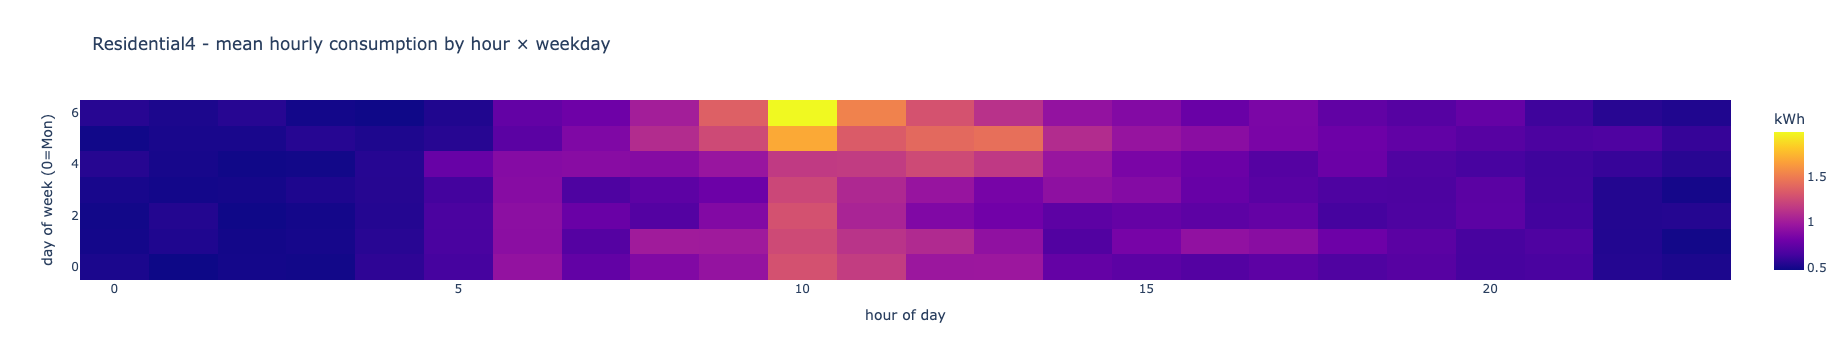

In [7]:
# hour-of-day vs day-of-week heatmap shows the diurnal + weekly structure the forecaster must learn
eda = hourly[['total_consumption']].copy()
eda['hour'] = eda.index.hour
eda['dow'] = eda.index.dayofweek
pivot = eda.groupby(['dow','hour'])['total_consumption'].mean().unstack()
fig = px.imshow(
    pivot, aspect='auto', origin='lower',
    labels=dict(x='hour of day', y='day of week (0=Mon)', color='kWh'),
    title='Residential4 - mean hourly consumption by hour × weekday',
)
fig.show()

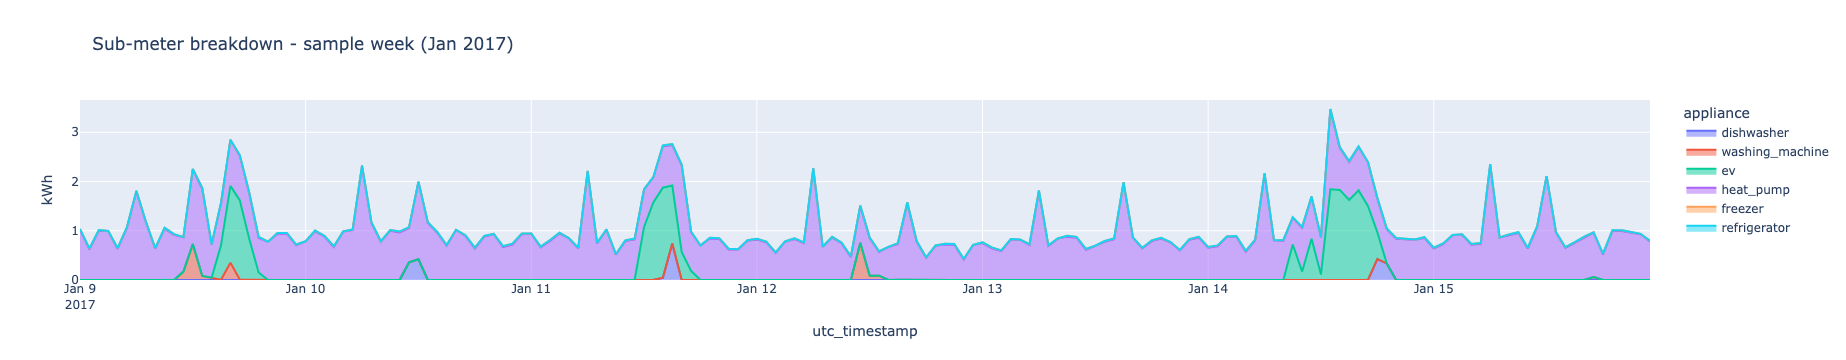

In [8]:
# sub-meter stacked area for a representative week - confirms which appliances are shiftable
sample = hourly.loc['2017-01-09':'2017-01-15', ['dishwasher','washing_machine','ev','heat_pump','freezer','refrigerator']].fillna(0)
fig = px.area(sample, title='Sub-meter breakdown - sample week (Jan 2017)', labels=dict(value='kWh', variable='appliance'))
fig.show()

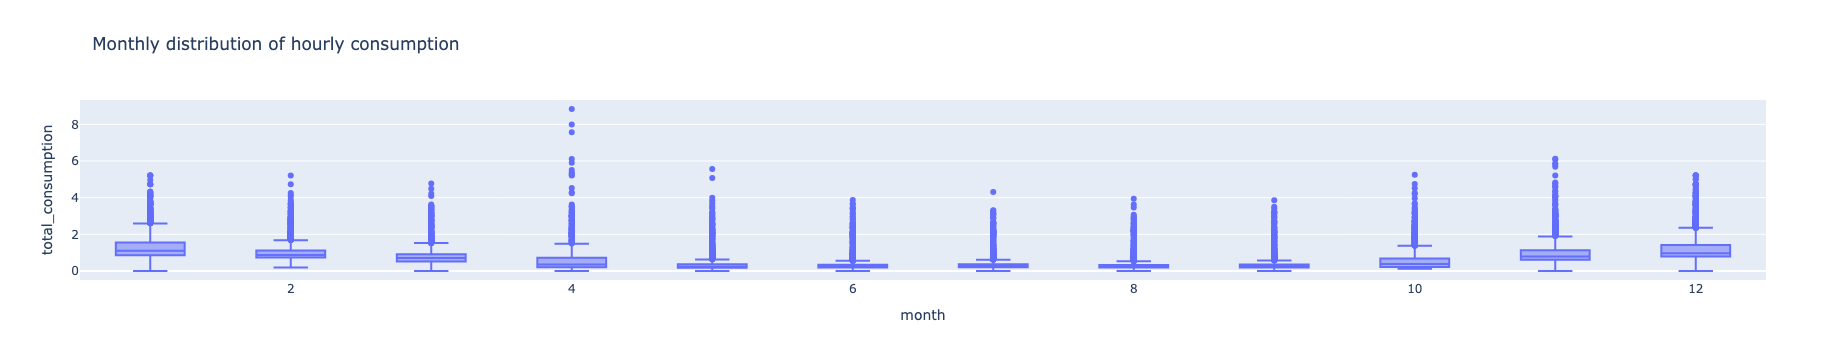

In [9]:
# monthly boxplot to expose seasonality (heat pump + lighting drive winter peaks)
mdf = eda.copy()
mdf['month'] = mdf.index.month
fig = px.box(mdf, x='month', y='total_consumption', title='Monthly distribution of hourly consumption')
fig.show()

## 5. Historical UK price context (motivation chart only)

Single motivational chart from the DESNZ historical series - never fed into any model.

In [10]:
# 'Electricity Prices' sheet has a 5-row preamble; real header is at row index 4
hist = pd.read_excel(DATA_DIR / 'Historical Electricity Data Since 1920.xlsx', sheet_name='Electricity Prices', header=4)
hist.columns = ['year','gdp_index','price_p_per_kwh','price_1990gdp','cpi_real_2010','ind_price_2010','source']
hist = hist.replace(r'\[x\]', np.nan, regex=True)
hist['year'] = pd.to_numeric(hist['year'], errors='coerce')
hist['price_p_per_kwh'] = pd.to_numeric(hist['price_p_per_kwh'], errors='coerce')
hist = hist.dropna(subset=['year','price_p_per_kwh'])
display(hist[['year','price_p_per_kwh']].tail(3))

/Users/abiskaracharya/Projects/electricity-project/.venv/lib/python3.13/site-packages/openpyxl/worksheet/header_footer.py:48: UserWarning:

Cannot parse header or footer so it will be ignored



,year,price_p_per_kwh
103,2022.0,23.2348
104,2023.0,28.8008
105,2024.0,26.0562


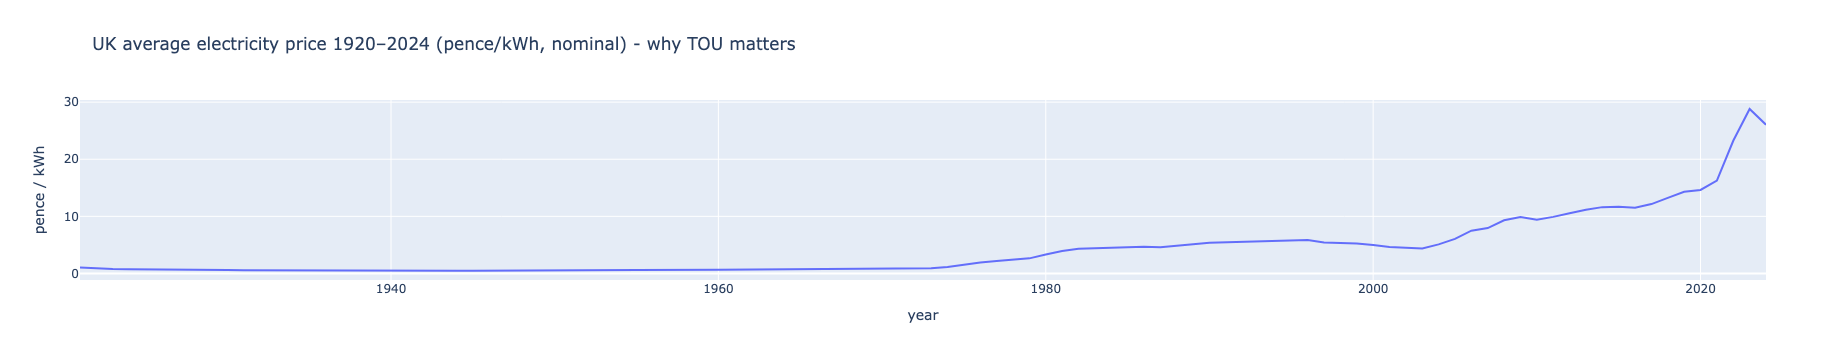

In [11]:
# single motivational chart: UK average selling price 1920–2024
fig = px.line(hist, x='year', y='price_p_per_kwh',
              title='UK average electricity price 1920–2024 (pence/kWh, nominal) - why TOU matters',
              labels=dict(year='year', price_p_per_kwh='pence / kWh'))
fig.show()

## 6. London TOU tariff - cyclic mapping

`London Tariffs.xlsx` has 30-minute Low / Normal / High labels for 2013 only. We aggregate to hourly (most common label per hour), then build a lookup keyed by `(day_of_week, hour_of_day)` and apply it cyclically to every household timestamp. **Assumption explicitly stated:** the UK weekday/hour tariff structure is reused verbatim for a German household whose dates (2014–2019) don't overlap the London record.

In [12]:
tar_raw = pd.read_excel(DATA_DIR / 'London Tariffs.xlsx')
display(tar_raw.head())
print(tar_raw.columns.tolist(), tar_raw.shape)

,TariffDateTime,Tariff
0,2013-01-01 00:00:00,Normal
1,2013-01-01 00:30:00,Normal
2,2013-01-01 01:00:00,Normal
3,2013-01-01 01:30:00,Normal
4,2013-01-01 02:00:00,Normal


['TariffDateTime', 'Tariff'] (17520, 2)


In [13]:
# normalise column names
tar = tar_raw.copy()
tar.columns = [str(c).strip().lower() for c in tar.columns]
ts_col = [c for c in tar.columns if 'date' in c or 'time' in c or 'tstp' in c][0]
label_col = [c for c in tar.columns if 'tariff' in c or 'stdor' in c or 'type' in c][-1]
tar[ts_col] = pd.to_datetime(tar[ts_col])
tar = tar.set_index(ts_col).sort_index()
# hourly aggregation - take the most common half-hour label per hour
hourly_tar = tar[label_col].resample('1h').agg(lambda s: s.mode().iat[0] if len(s.mode()) else np.nan).dropna()
hourly_tar = hourly_tar.rename('tariff_label')
display(hourly_tar.value_counts())

tariff_label
Normal    7536
Low        830
High       394
Name: count, dtype: int64

In [14]:
# Build cyclic lookup: for each (dow, hour) across 2013, measure the fraction of days labelled Low/High.
# London dToU signals Low/High as day-ahead exceptions, so modal aggregation collapses to Normal.
# Threshold rule keeps a canonical cyclic shape derived from the real data.
tmp = hourly_tar.to_frame()
tmp['dow'] = tmp.index.dayofweek
tmp['hour'] = tmp.index.hour
def label_fracs(s):
    vc = s.value_counts(normalize=True)
    return pd.Series({'Low': vc.get('Low', 0.0), 'High': vc.get('High', 0.0)})
fracs = tmp.groupby(['dow','hour'])['tariff_label'].apply(label_fracs).unstack()
def assign(row):
    if row['Low']  >= 0.15: return 'Low'
    if row['High'] >= 0.10: return 'High'
    return 'Normal'
fracs['tariff_label'] = fracs.apply(assign, axis=1)
lookup = fracs.reset_index()[['dow','hour','tariff_label']]
price_map = {'Low': 0.05, 'Normal': 0.13, 'High': 0.32}
lookup['tariff_price'] = lookup['tariff_label'].map(price_map)
display(lookup['tariff_label'].value_counts())
display(lookup.head(8))
lookup.to_parquet(PROC / 'tariff_lookup.parquet')

tariff_label
Normal    129
Low        24
High       15
Name: count, dtype: int64

,dow,hour,tariff_label,tariff_price
0,0,0,Low,0.05
1,0,1,Low,0.05
2,0,2,Normal,0.13
3,0,3,Normal,0.13
4,0,4,Normal,0.13
5,0,5,Normal,0.13
6,0,6,Normal,0.13
7,0,7,Normal,0.13


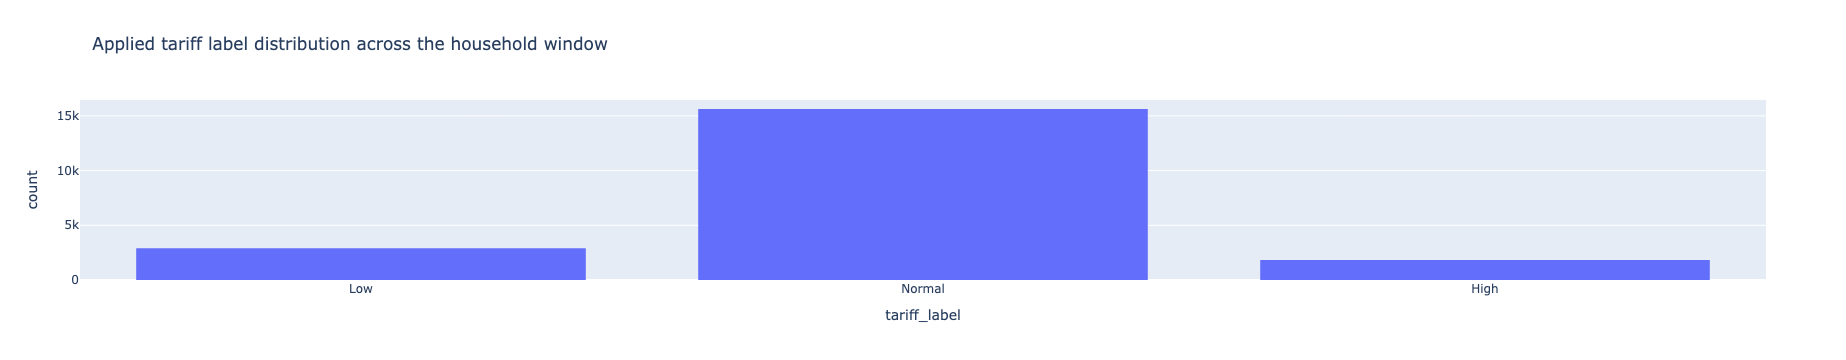

In [15]:
# join the cyclic lookup onto the household frame
hourly['dow'] = hourly.index.dayofweek
hourly['hour'] = hourly.index.hour
hourly = hourly.merge(lookup, on=['dow','hour'], how='left').set_index(hourly.index)
fig = px.histogram(hourly, x='tariff_label', title='Applied tariff label distribution across the household window', category_orders={'tariff_label': ['Low','Normal','High']})
fig.show()

## 7. Weather - Open-Meteo historical for Konstanz

In [16]:
start_d = hourly.index.min().strftime('%Y-%m-%d')
end_d = hourly.index.max().strftime('%Y-%m-%d')
url = (
    'https://archive-api.open-meteo.com/v1/archive'
    f'?latitude=47.66&longitude=9.18&start_date={start_d}&end_date={end_d}'
    '&hourly=temperature_2m,relative_humidity_2m,shortwave_radiation,wind_speed_10m'
    '&timezone=UTC'
)
r = requests.get(url, timeout=60); r.raise_for_status()
w = pd.DataFrame(r.json()['hourly'])
w['time'] = pd.to_datetime(w['time'], utc=True)
w = w.set_index('time')
display(w.head())
print(w.shape)

,temperature_2m,relative_humidity_2m,shortwave_radiation,wind_speed_10m
time,,,,
2015-10-10 00:00:00+00:00,11.3,86,0.0,8.8
2015-10-10 01:00:00+00:00,11.0,88,0.0,10.0
2015-10-10 02:00:00+00:00,10.7,90,0.0,10.0
2015-10-10 03:00:00+00:00,10.5,90,0.0,9.4
2015-10-10 04:00:00+00:00,10.3,91,0.0,9.2


(20376, 4)


In [17]:
df = hourly.join(w, how='left')
df[w.columns] = df[w.columns].ffill(limit=3)
print('post-merge shape:', df.shape)
print('nulls:', df[w.columns].isna().sum().to_dict())

post-merge shape: (20359, 19)
nulls: {'temperature_2m': 0, 'relative_humidity_2m': 0, 'shortwave_radiation': 0, 'wind_speed_10m': 0}


## 8. Feature engineering

In [18]:
# lag and rolling features on the target (baseline non-shiftable load)
y = df['baseline_load']
df['lag_1h']   = y.shift(1)
df['lag_24h']  = y.shift(24)
df['lag_168h'] = y.shift(168)
df['roll_3h']  = y.shift(1).rolling(3).mean()
df['roll_24h'] = y.shift(1).rolling(24).mean()

In [19]:
# cyclic calendar encodings so tree models can read phase without discontinuity bias
idx = df.index
df['hour_sin']  = np.sin(2*np.pi*idx.hour/24)
df['hour_cos']  = np.cos(2*np.pi*idx.hour/24)
df['dow_sin']   = np.sin(2*np.pi*idx.dayofweek/7)
df['dow_cos']   = np.cos(2*np.pi*idx.dayofweek/7)
df['month_sin'] = np.sin(2*np.pi*idx.month/12)
df['month_cos'] = np.cos(2*np.pi*idx.month/12)
df['is_weekend']  = (idx.dayofweek >= 5).astype(int)
df['is_peak_hour']= idx.hour.isin([17,18,19,20]).astype(int)
df['tariff_period'] = df['tariff_label'].map({'Low':0,'Normal':1,'High':2}).astype('Int64')

In [20]:
feature_cols = [
    'lag_1h','lag_24h','lag_168h','roll_3h','roll_24h',
    'hour_sin','hour_cos','dow_sin','dow_cos','month_sin','month_cos',
    'is_weekend','is_peak_hour','tariff_period','tariff_price',
    'temperature_2m','relative_humidity_2m','shortwave_radiation','wind_speed_10m',
]
model_df = df[feature_cols + ['baseline_load']].dropna()
print('rows after dropping lag/roll warm-up NaNs:', len(model_df))
display(model_df.head(3))

rows after dropping lag/roll warm-up NaNs: 20191


,lag_1h,lag_24h,lag_168h,roll_3h,roll_24h,hour_sin,hour_cos,dow_sin,dow_cos,month_sin,month_cos,is_weekend,is_peak_hour,tariff_period,tariff_price,temperature_2m,relative_humidity_2m,shortwave_radiation,wind_speed_10m,baseline_load
utc_timestamp,,,,,,,,,,,,,,,,,,,,
2015-10-17 17:00:00+00:00,0.260,0.351,0.813,0.209000,0.260083,-0.965926,-2.588190e-01,-0.974928,-0.222521,-0.866025,0.5,1,1,2,0.32,8.6,74,2.0,1.1,0.382
2015-10-17 18:00:00+00:00,0.382,0.307,0.735,0.290333,0.261375,-1.000000,-1.836970e-16,-0.974928,-0.222521,-0.866025,0.5,1,1,2,0.32,8.3,77,0.0,0.8,0.317
2015-10-17 19:00:00+00:00,0.317,0.228,0.345,0.319667,0.261792,-0.965926,2.588190e-01,-0.974928,-0.222521,-0.866025,0.5,1,1,2,0.32,7.5,84,0.0,0.7,0.263


## 9. Chronological 80/20 split and persist

In [21]:
split_ts = model_df.index[int(len(model_df) * 0.8)]
X = model_df[feature_cols]
y = model_df['baseline_load']
X_train, X_test = X.loc[:split_ts].iloc[:-1], X.loc[split_ts:]
y_train, y_test = y.loc[:split_ts].iloc[:-1], y.loc[split_ts:]
print(f'train {X_train.shape} {X_train.index.min()} -> {X_train.index.max()}')
print(f'test  {X_test.shape} {X_test.index.min()} -> {X_test.index.max()}')

train (16152, 19) 2015-10-17 17:00:00+00:00 -> 2017-08-20 16:00:00+00:00
test  (4039, 19) 2017-08-20 17:00:00+00:00 -> 2018-02-04 23:00:00+00:00


In [22]:
X_train.to_parquet(PROC / 'X_train.parquet')
X_test.to_parquet(PROC / 'X_test.parquet')
y_train.to_frame('y').to_parquet(PROC / 'y_train.parquet')
y_test.to_frame('y').to_parquet(PROC / 'y_test.parquet')

# also save the full hourly frame (sub-meters kept) for scheduler calibration in notebook 2
df.to_parquet(PROC / 'hourly_full.parquet')

## 10. Appliance specs - calibrated from the sub-meter traces

The MILP scheduler needs (power kW, run duration hours, earliest start, latest finish, quiet hours) per shiftable appliance. We calibrate power and duration from residential4's own traces.

In [23]:
def calibrate(series, threshold=0.05):
    # mean power when the appliance is 'on' and typical contiguous run-length in hours
    on = series > threshold
    power = series[on].mean()
    # contiguous on-runs
    runs = []
    cur = 0
    for v in on.values:
        if v: cur += 1
        elif cur: runs.append(cur); cur = 0
    if cur: runs.append(cur)
    duration = int(np.median(runs)) if runs else 1
    return round(float(power), 3), max(1, duration)

specs = []
for app, earliest, latest, quiet in [
    ('dishwasher',     6, 23, []),
    ('washing_machine',7, 22, []),
    ('ev',             0, 23, []),
    ('heat_pump',      0, 23, []),
]:
    if app in hourly.columns:
        p, d = calibrate(hourly[app].dropna())
        specs.append({'appliance': app, 'power_kw': p, 'duration_h': d,
                      'earliest': earliest, 'latest': latest, 'quiet_hours': quiet})
specs_df = pd.DataFrame(specs)
display(specs_df)
specs_df.to_parquet(PROC / 'appliance_specs.parquet')

,appliance,power_kw,duration_h,earliest,latest,quiet_hours
0,dishwasher,0.423,2,6,23,[]
1,washing_machine,0.292,3,7,22,[]
2,ev,1.190,3,0,23,[]
3,heat_pump,0.672,8,0,23,[]


Notebook 1 complete. Artefacts written to `../data/processed/`:

- `X_train.parquet`, `X_test.parquet`, `y_train.parquet`, `y_test.parquet`
- `hourly_full.parquet` (full merged frame incl. sub-meters)
- `tariff_lookup.parquet` (cyclic dow × hour tariff map)
- `appliance_specs.parquet` (calibrated per-appliance parameters for the MILP)

Proceed to `02_models_scheduler_explainability.ipynb`.